# 26. Contract personalization v6 — phase-aware in-session feedback

This notebook tests whether feedback should react differently across the personalization session:

- early feedback = stronger steering / rescue;
- middle feedback = normal correction;
- late feedback = still audible, but less likely to throw away refinement.

The baseline is the previous constant-strength cosine feedback.


In [16]:

from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
TABLES_DIR = OUTPUT_DIR / "tables"
for p in [FIGURES_DIR, METRICS_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization.state import FEATURE_NAMES_8D
from personalization.synthetic_dataset import generate_synthetic_users_dataset, row_to_synthetic_user
from personalization.contract_mapper import InterpretableContractMapper8D, FREQS_23_DEFAULT
from personalization.contract_pair_generator import ContractPairConfig
from personalization.contract_session import (
    ContractSessionConfig,
    run_contract_personalization_session,
    contract_records_dataframe,
    contract_summary_dataframe,
)
from personalization.contract_feedback import feedback_labels_table
from personalization.plotting import use_article_style

use_article_style()


def savefig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)



def _short_strategy_name(name: str) -> str:
    return (
        str(name)
        .replace("semantic_", "sem_")
        .replace("phase_", "ph_")
        .replace("_feedback", "_fb")
        .replace("_contract_v6", "")
    )


def add_ready_markers(ax, summary_df, strategies, *, mode="zone"):
    """Add soft-stop markers without rotated overlapping labels.

    mode="zone" draws a compact ready band when several strategies have close
    ready steps. It also adds a small textbox with exact mean marker values.
    """
    rows = []
    for strategy in strategies:
        ready = summary_df.loc[summary_df["strategy"] == strategy, "ready_step"].dropna()
        if len(ready) == 0:
            continue
        rows.append((str(strategy), float(ready.mean())))

    if not rows:
        return

    xs = np.asarray([x for _, x in rows], dtype=float)
    xmin, xmax = float(xs.min()), float(xs.max())
    xmean = float(xs.mean())

    if mode == "zone" or len(rows) > 2:
        pad = max(0.12, 0.15 * (xmax - xmin + 1e-6))
        ax.axvspan(
            xmin - pad,
            xmax + pad,
            color="0.35",
            alpha=0.08,
            label=f"ready zone ≈ {xmean:.1f}",
            zorder=0,
        )
        ax.axvline(xmean, color="0.35", linestyle="--", alpha=0.35, linewidth=1.6)
    else:
        for _, x in rows:
            ax.axvline(x, color="0.35", linestyle="--", alpha=0.30, linewidth=1.4)

    ymin, ymax = ax.get_ylim()
    y_marker = ymin + (ymax - ymin) * 0.96
    for _, x in rows:
        ax.scatter([x], [y_marker], marker="v", s=45, color="0.25", alpha=0.75, zorder=5)

    text = "\n".join(f"{_short_strategy_name(strategy)}: ready≈{x:.1f}" for strategy, x in rows)
    ax.text(
        0.985,
        0.04,
        text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.7", alpha=0.78),
    )


## Feedback labels

Проверяем, какие направления rule-based feedback меняют в `z_contract`.

In [17]:

feedback_table = feedback_labels_table()
feedback_table.to_csv(TABLES_DIR / "v6_feedback_phaseaware_labels_table.csv", index=False)
feedback_table


,feedback_label,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
0,too_much_bass,-0.16,-0.22,-0.05,0.00,0.00,0.00,0.00,0.08
1,not_enough_bass,0.16,0.22,0.03,0.00,0.00,0.00,0.00,-0.05
2,too_bright,0.02,0.03,0.02,0.03,-0.06,-0.12,-0.18,-0.22
3,too_dark,-0.02,-0.02,-0.02,-0.03,0.06,0.12,0.18,0.22
4,too_muddy,0.00,-0.06,-0.18,-0.12,0.04,0.08,0.03,0.08
5,too_thin,0.08,0.12,0.12,0.10,-0.02,-0.02,0.00,-0.04
6,more_presence,0.00,0.00,-0.03,0.00,0.18,0.08,0.00,0.05
7,less_presence,0.00,0.00,0.03,0.00,-0.18,-0.08,0.00,-0.05
8,more_air,0.00,0.00,0.00,0.00,0.02,0.08,0.22,0.12
9,less_air,0.00,0.00,0.00,0.00,-0.02,-0.08,-0.22,-0.12


## Generate synthetic users

Используем тот же contract-space dataset, что и в v6/v6.2, чтобы сравнение было сопоставимым.

In [18]:

SEED = 42
N_PER_MODE = 40
MAX_USERS = 80

users_df = generate_synthetic_users_dataset(
    n_per_mode=N_PER_MODE,
    seed=SEED,
    noise_std=0.03,
    target_max_abs=2.0,
    archetype_extreme_probability=0.35,
)

users_df.to_csv(TABLES_DIR / "v6_feedback_phaseaware_synthetic_users.csv", index=False)
print("rows:", len(users_df))
users_df["target_mode"].value_counts()


rows: 160


target_mode
random8d       40
semantic4d     40
semantic6d     40
archetype8d    40
Name: count, dtype: int64

## Run feedback ablation

Feedback выбирается стохастически: даже если оба варианта плохие, виртуальный пользователь не обязан нажимать feedback.

`cosine_feedback` выбирает label по направлению, наиболее близкому к скрытому `target - pair_center`, но всё равно применяет ограниченную вероятность и cooldown.

In [19]:

mapper = InterpretableContractMapper8D(freqs_hz=FREQS_23_DEFAULT, safety=True)

pair_cfg = ContractPairConfig(
    step_scale=0.46,
    max_pair_distance_z=1.25,
    min_pair_distance_z=0.14,
    max_pair_distance_db_rms=6.8,
    max_candidate_abs_db=12.5,
)

BASE_SESSION_KWARGS = dict(
    min_ready_step=16,
    ready_mean_std_threshold=0.60,
    ready_update_norm_threshold=0.25,
    ready_distance_z_threshold=0.90,
    ready_distance_db_rms_threshold=1.55,
    ready_distance_step_window=4,
    ready_min_gain_z=0.035,
    ready_min_gain_db_rms=0.08,

    phase_warmup_steps=3,
    phase_semantic_until_step=17,
    phase_axis_every=5,
    phase_candidate_pool_every=7,

    post_marker_use_direct=True,
    post_marker_probe_window=3,
    post_marker_probe_min_gain_z=0.025,
    post_marker_probe_min_gain_db_rms=0.070,
    post_marker_semantic_probability=0.70,
    post_marker_direct_probability=0.20,
    post_marker_axis_probability=0.07,
    post_marker_candidate_pool_probability=0.03,
    direct_mode="trust",
)

# Previous constant feedback baseline.
FEEDBACK_FIXED_KWARGS = dict(
    enable_feedback=True,
    feedback_policy="hybrid",
    feedback_min_step=4,
    feedback_cooldown_steps=2,
    feedback_strength=1.0,
    feedback_phase_aware=False,
    feedback_max_probability=0.34,
    feedback_base_probability=0.015,
    feedback_random_probability=0.12,
    feedback_bad_distance_z=0.95,
    feedback_cosine_threshold=0.42,
    feedback_ambiguity_margin=0.18,
    feedback_misalignment_weight=0.35,
    feedback_model_lr=0.35,
)

# New phase-aware feedback. Late feedback is softer than early feedback, but it is
# deliberately not tiny: late feedback should still be audible in the mapped EQ.
FEEDBACK_PHASE_AWARE_KWARGS = dict(
    FEEDBACK_FIXED_KWARGS,
    feedback_phase_aware=True,
    feedback_early_until_step=6,
    feedback_late_from_step=17,
    feedback_early_strength_multiplier=1.35,
    feedback_mid_strength_multiplier=1.00,
    feedback_late_strength_multiplier=0.82,
    feedback_min_audible_strength=0.70,
    feedback_early_std_decay=0.82,
    feedback_mid_std_decay=0.88,
    feedback_late_std_decay=0.93,
    feedback_early_model_lr_multiplier=1.15,
    feedback_mid_model_lr_multiplier=1.00,
    feedback_late_model_lr_multiplier=0.85,
)

SCENARIOS = [
    dict(label="semantic_no_feedback", strategy="semantic_contract_v6", kwargs=dict(enable_feedback=False)),
    dict(label="semantic_cosine_fixed", strategy="semantic_contract_v6", kwargs=FEEDBACK_FIXED_KWARGS),
    dict(label="semantic_cosine_phaseaware", strategy="semantic_contract_v6", kwargs=FEEDBACK_PHASE_AWARE_KWARGS),
    dict(label="phase_cosine_fixed", strategy="phase_mixed_contract_v6", kwargs=FEEDBACK_FIXED_KWARGS),
    dict(label="phase_cosine_phaseaware", strategy="phase_mixed_contract_v6", kwargs=FEEDBACK_PHASE_AWARE_KWARGS),
]


def run_feedback_scenarios(dataset, scenarios, max_users=80, n_steps=25, seed=42):
    df = dataset.copy()
    if max_users is not None and len(df) > int(max_users):
        df = df.sample(n=int(max_users), random_state=seed).reset_index(drop=True)

    results = []
    for scenario_idx, scenario in enumerate(scenarios):
        label = scenario["label"]
        strategy = scenario["strategy"]
        kwargs = dict(BASE_SESSION_KWARGS)
        kwargs.update(scenario.get("kwargs", {}))
        print("running", label, "phase_aware=", kwargs.get("feedback_phase_aware", False))

        for row_idx, row in df.iterrows():
            user_seed = int(seed + scenario_idx * 100000 + row_idx * 1009 + abs(hash(label)) % 997)
            user = row_to_synthetic_user(row, seed=user_seed)
            cfg = ContractSessionConfig(
                strategy=strategy,
                experiment_label=label,
                n_steps=n_steps,
                seed=user_seed,
                pair_config=pair_cfg,
                **kwargs,
            )
            result = run_contract_personalization_session(
                synthetic_user=user,
                target_mode=str(row.get("target_mode", "unknown")),
                config=cfg,
                mapper=mapper,
            )
            results.append(result)
    return results


results = run_feedback_scenarios(
    users_df,
    SCENARIOS,
    max_users=MAX_USERS,
    n_steps=25,
    seed=SEED,
)

len(results)


running semantic_no_feedback phase_aware= False
running semantic_cosine_fixed phase_aware= False
running semantic_cosine_phaseaware phase_aware= True
running phase_cosine_fixed phase_aware= False
running phase_cosine_phaseaware phase_aware= True


400

## Summary tables

In [20]:

summary = contract_summary_dataframe(results)
records = contract_records_dataframe(results)

summary.to_csv(METRICS_DIR / "v6_feedback_phaseaware_session_summary.csv", index=False)
records.to_csv(METRICS_DIR / "v6_feedback_phaseaware_session_steps.csv", index=False)

verdict = summary.groupby("strategy").agg(
    users=("final_distance_z", "size"),
    mean_final_distance_z=("final_distance_z", "mean"),
    mean_final_distance_db_rms=("final_distance_db_rms", "mean"),
    mean_final_max_abs_db=("final_mapped_max_abs_db", "mean"),
    ready_rate=("ready_step", lambda s: float(s.notna().mean())),
    mean_ready_step=("ready_step", "mean"),
    mean_extra_gain_db_after_ready=("extra_gain_db_after_ready", "mean"),
    mean_feedback_count=("feedback_count", "mean"),
    mean_feedback_rate=("feedback_rate", "mean"),
).reset_index().sort_values("mean_final_distance_db_rms")

verdict.to_csv(TABLES_DIR / "v6_feedback_phaseaware_strategy_verdict.csv", index=False)
verdict


,strategy,users,mean_final_distance_z,mean_final_distance_db_rms,mean_final_max_abs_db,ready_rate,mean_ready_step,mean_extra_gain_db_after_ready,mean_feedback_count,mean_feedback_rate
2,semantic_cosine_fixed,80,0.649831,0.928147,7.852772,0.9875,16.924051,0.244296,1.2250,0.0490
0,phase_cosine_fixed,80,0.678736,0.987558,7.494475,0.9750,16.974359,0.273956,1.2875,0.0515
3,semantic_cosine_phaseaware,80,0.668631,0.994043,7.659480,0.9875,17.164557,0.279324,1.1250,0.0450
1,phase_cosine_phaseaware,80,0.685521,1.006745,7.270327,0.9875,16.936709,0.222131,1.2500,0.0500
4,semantic_no_feedback,80,0.708492,1.055732,7.436496,0.9125,16.890411,0.298654,0.0000,0.0000


In [21]:

summary_by_target = summary.groupby(["strategy", "target_mode"]).agg(
    users=("final_distance_z", "size"),
    mean_final_distance_z=("final_distance_z", "mean"),
    mean_final_distance_db_rms=("final_distance_db_rms", "mean"),
    mean_feedback_count=("feedback_count", "mean"),
    mean_feedback_rate=("feedback_rate", "mean"),
    mean_final_max_abs_db=("final_mapped_max_abs_db", "mean"),
).reset_index()

summary_by_target.to_csv(TABLES_DIR / "v6_feedback_phaseaware_summary_by_target.csv", index=False)
summary_by_target.sort_values(["target_mode", "mean_final_distance_db_rms"])


,strategy,target_mode,users,mean_final_distance_z,mean_final_distance_db_rms,mean_feedback_count,mean_feedback_rate,mean_final_max_abs_db
16,semantic_no_feedback,archetype8d,16,0.301890,0.471123,0.000000,0.000000,4.712212
12,semantic_cosine_phaseaware,archetype8d,16,0.292796,0.508377,0.937500,0.037500,4.779850
0,phase_cosine_fixed,archetype8d,16,0.322438,0.518468,1.000000,0.040000,4.675335
8,semantic_cosine_fixed,archetype8d,16,0.320396,0.585425,0.937500,0.037500,4.993543
4,phase_cosine_phaseaware,archetype8d,16,0.341680,0.596031,0.875000,0.035000,4.182609
9,semantic_cosine_fixed,random8d,24,1.265326,1.441787,1.333333,0.053333,6.991791
1,phase_cosine_fixed,random8d,24,1.281055,1.525136,1.000000,0.040000,6.881643
5,phase_cosine_phaseaware,random8d,24,1.319592,1.587585,1.250000,0.050000,6.299806
13,semantic_cosine_phaseaware,random8d,24,1.285789,1.604068,1.291667,0.051667,7.038387
17,semantic_no_feedback,random8d,24,1.357477,1.651674,0.000000,0.000000,6.882683


## Feedback usage

In [22]:

feedback_usage = (
    records[records["feedback_used"] == True]
    .groupby(["strategy", "feedback_label"])
    .size()
    .reset_index(name="count")
)
if len(feedback_usage):
    feedback_usage["share_pct"] = feedback_usage.groupby("strategy")["count"].transform(lambda s: 100 * s / s.sum())
feedback_usage.to_csv(TABLES_DIR / "v6_feedback_phaseaware_label_usage.csv", index=False)
feedback_usage.sort_values(["strategy", "count"], ascending=[True, False])


,strategy,feedback_label,count,share_pct
9,phase_cosine_fixed,too_much_bass,26,25.242718
3,phase_cosine_fixed,more_presence,13,12.621359
0,phase_cosine_fixed,less_air,12,11.650485
1,phase_cosine_fixed,less_presence,9,8.737864
4,phase_cosine_fixed,not_enough_bass,9,8.737864
2,phase_cosine_fixed,more_air,5,4.854369
6,phase_cosine_fixed,too_bright,5,4.854369
10,phase_cosine_fixed,too_muddy,5,4.854369
13,phase_cosine_fixed,vocal_hidden,5,4.854369
7,phase_cosine_fixed,too_dark,4,3.883495


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_rate_by_step.png


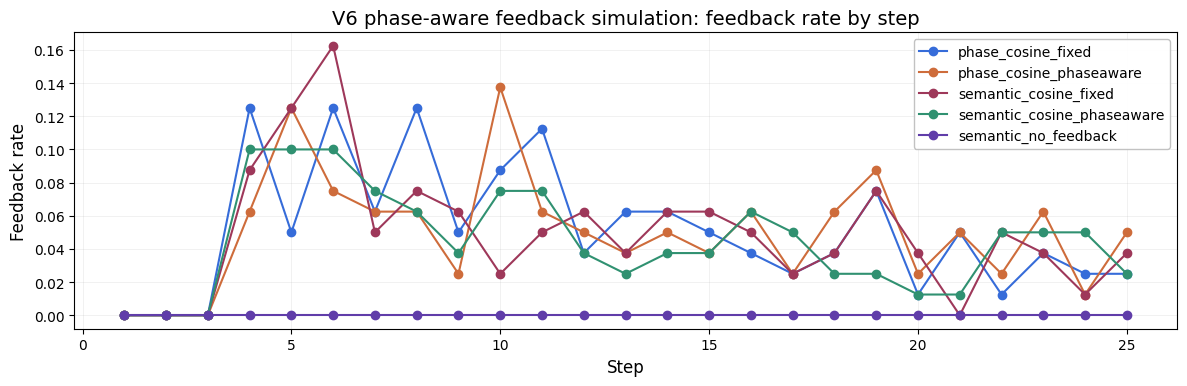

In [23]:

feedback_by_step = (
    records
    .groupby(["strategy", "step"])
    .agg(feedback_rate=("feedback_used", "mean"), questions=("step", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
for strategy, g in feedback_by_step.groupby("strategy"):
    ax.plot(g["step"], g["feedback_rate"], marker="o", label=strategy)
ax.set_title("V6 phase-aware feedback simulation: feedback rate by step")
ax.set_xlabel("Step")
ax.set_ylabel("Feedback rate")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
savefig("v6_feedback_phaseaware_rate_by_step.png")
plt.show()


## Feedback phase usage


In [24]:

# Feedback phase usage: early / mid / late / constant
feedback_phase_usage = (
    records[records["feedback_used"].astype(bool)]
    .groupby(["strategy", "feedback_phase"])
    .size()
    .reset_index(name="events")
)
feedback_phase_usage["share_pct"] = (
    100 * feedback_phase_usage["events"] / feedback_phase_usage.groupby("strategy")["events"].transform("sum")
)
feedback_phase_usage.to_csv(TABLES_DIR / "v6_feedback_phaseaware_phase_usage.csv", index=False)
feedback_phase_usage


,strategy,feedback_phase,events,share_pct
0,phase_cosine_fixed,constant,103,100.000000
1,phase_cosine_phaseaware,early,21,21.000000
2,phase_cosine_phaseaware,late,32,32.000000
3,phase_cosine_phaseaware,mid,47,47.000000
4,semantic_cosine_fixed,constant,98,100.000000
5,semantic_cosine_phaseaware,early,24,26.666667
6,semantic_cosine_phaseaware,late,24,26.666667
7,semantic_cosine_phaseaware,mid,42,46.666667


## Source usage

`feedback_recovery_contract` должен появляться на шаге после feedback.

In [25]:

source_usage = (
    records
    .groupby(["strategy", "pair_source_group"])
    .size()
    .reset_index(name="questions")
)
source_usage["share_pct"] = source_usage.groupby("strategy")["questions"].transform(lambda s: 100 * s / s.sum())
source_usage.to_csv(TABLES_DIR / "v6_feedback_phaseaware_pair_source_usage.csv", index=False)
source_usage.sort_values(["strategy", "questions"], ascending=[True, False])


,strategy,pair_source_group,questions,share_pct
4,phase_cosine_fixed,semantic_contract,1574,78.70
1,phase_cosine_fixed,candidate_pool_contract,254,12.70
3,phase_cosine_fixed,feedback_recovery_contract,101,5.05
2,phase_cosine_fixed,direct_trust_contract,45,2.25
0,phase_cosine_fixed,axis_contract,26,1.30
9,phase_cosine_phaseaware,semantic_contract,1600,80.00
6,phase_cosine_phaseaware,candidate_pool_contract,249,12.45
8,phase_cosine_phaseaware,feedback_recovery_contract,96,4.80
7,phase_cosine_phaseaware,direct_trust_contract,35,1.75
5,phase_cosine_phaseaware,axis_contract,20,1.00


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_source_usage_by_step_phase_cosine_fixed.png


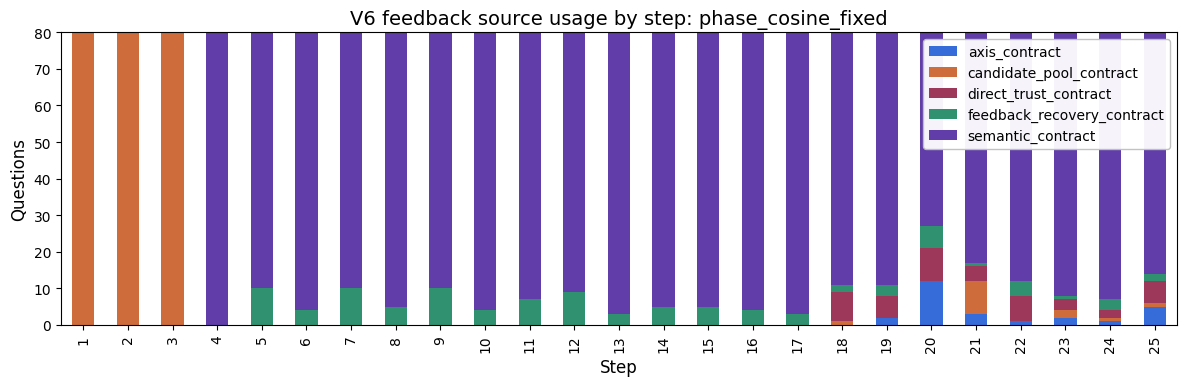

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_source_usage_by_step_phase_cosine_phaseaware.png


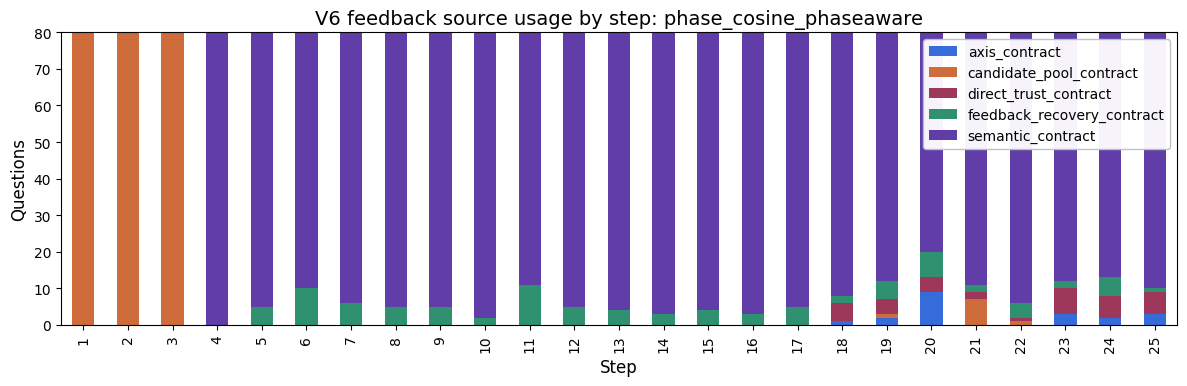

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_source_usage_by_step_semantic_cosine_fixed.png


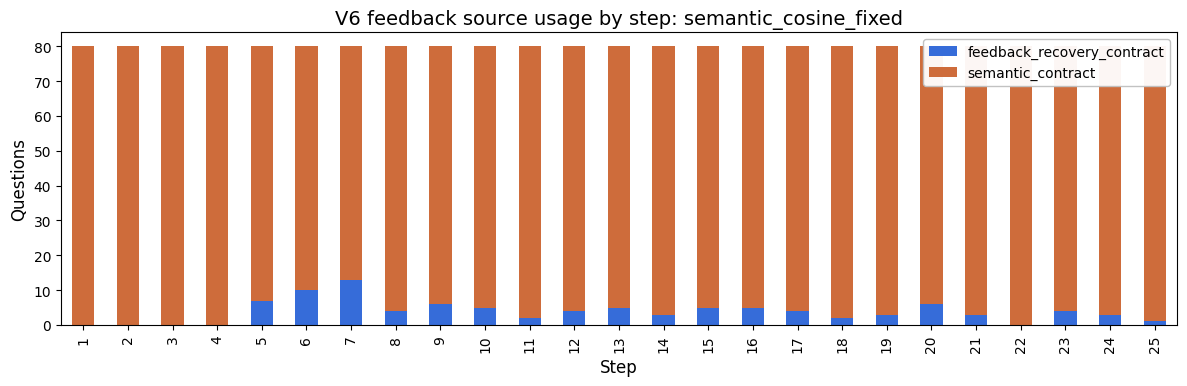

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_source_usage_by_step_semantic_cosine_phaseaware.png


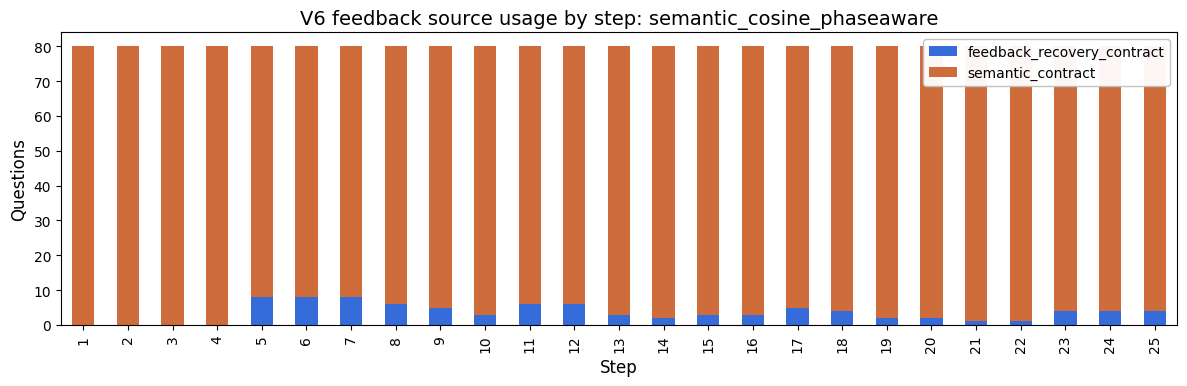

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_source_usage_by_step_semantic_no_feedback.png


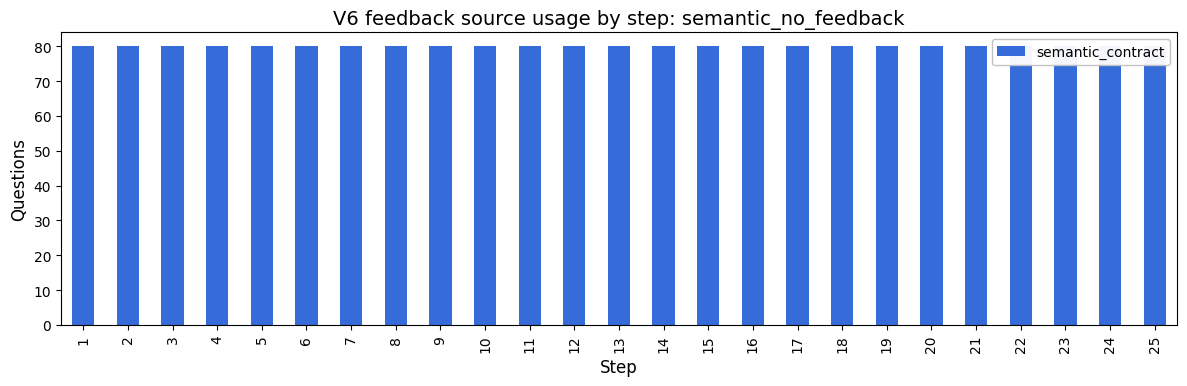

In [26]:

step_source = (
    records
    .groupby(["strategy", "step", "pair_source_group"])
    .size()
    .reset_index(name="questions")
)

for strategy, g in step_source.groupby("strategy"):
    pivot_source = g.pivot_table(
        index="step",
        columns="pair_source_group",
        values="questions",
        aggfunc="sum",
        fill_value=0,
    )
    ax = pivot_source.plot(kind="bar", stacked=True, figsize=(12, 4))
    ax.set_title(f"V6 feedback source usage by step: {strategy}")
    ax.set_xlabel("Step")
    ax.set_ylabel("Questions")
    ax.legend(loc="best")
    plt.tight_layout()
    safe = strategy.replace("/", "_")
    savefig(f"v6_feedback_phaseaware_source_usage_by_step_{safe}.png")
    plt.show()


## Convergence plots

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_convergence_distance_z.png


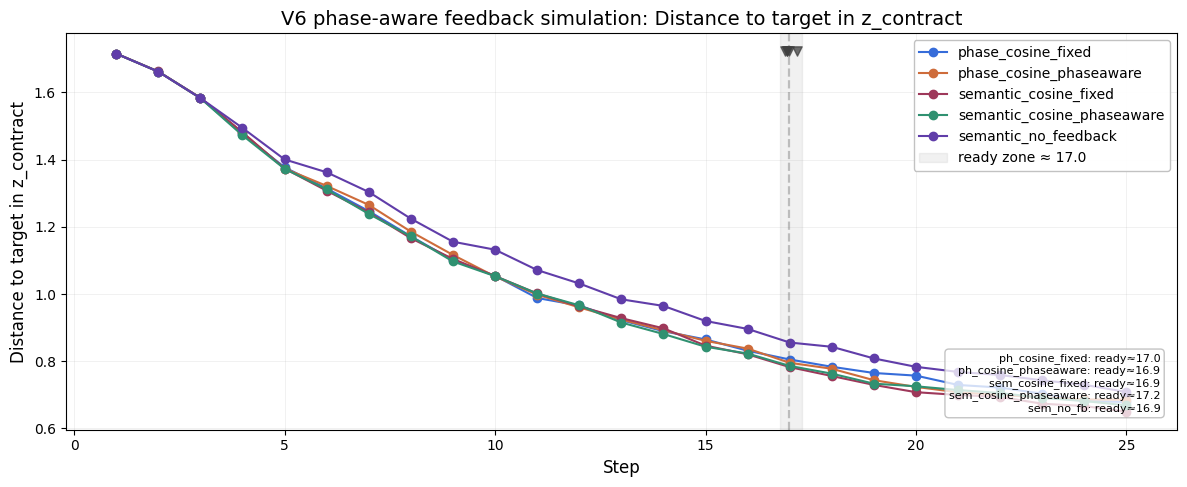

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_convergence_distance_db.png


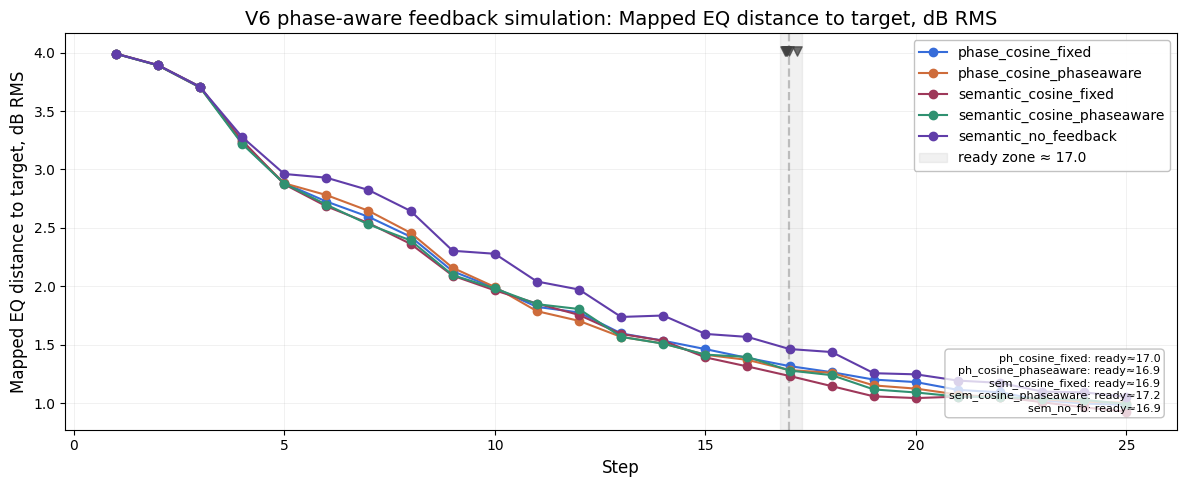

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_convergence_max_abs_db.png


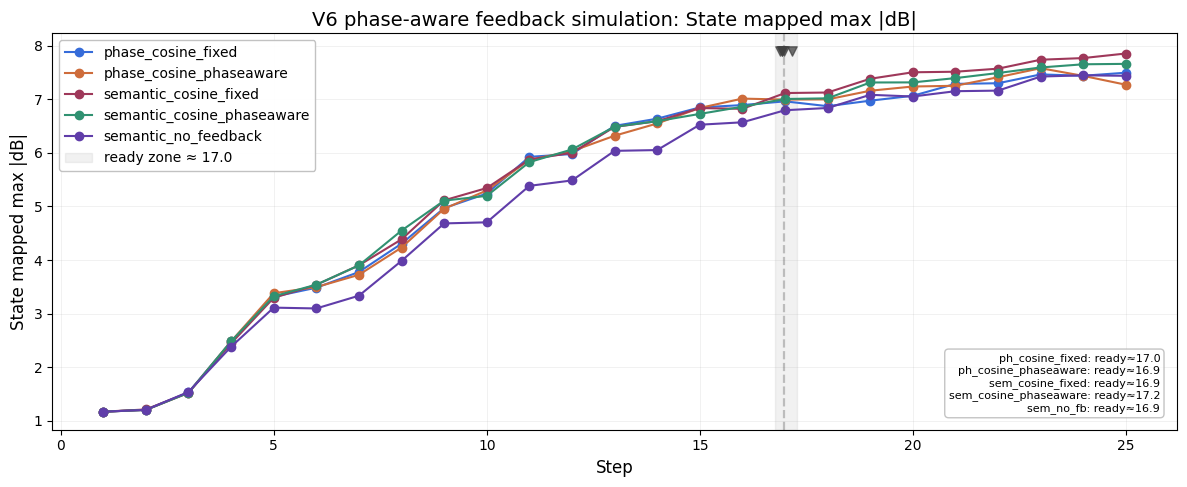

saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_convergence_pair_max_abs_db.png


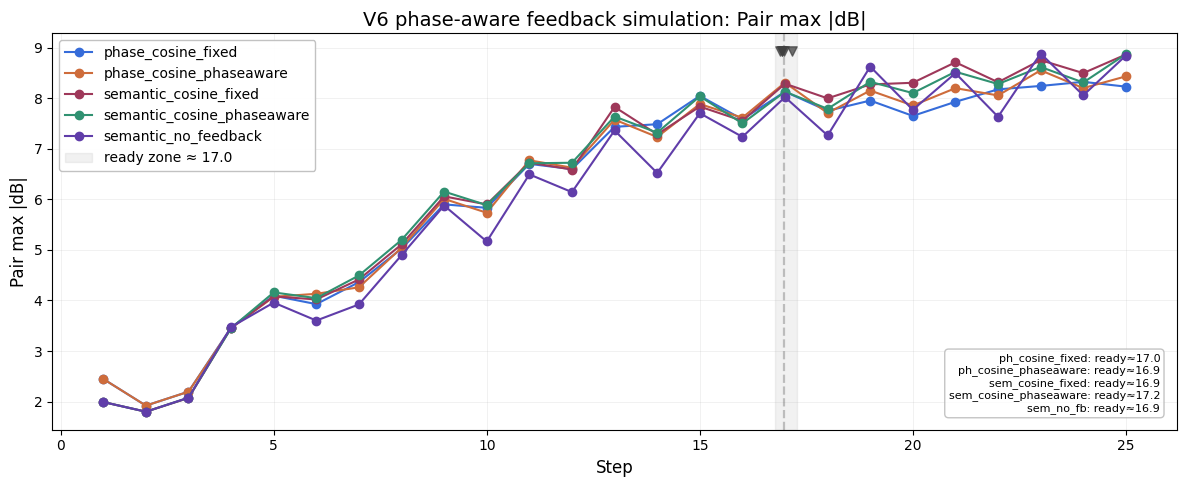

In [27]:

for metric, ylabel, filename in [
    ("distance_to_target_z", "Distance to target in z_contract", "v6_feedback_phaseaware_convergence_distance_z.png"),
    ("distance_to_target_db_rms", "Mapped EQ distance to target, dB RMS", "v6_feedback_phaseaware_convergence_distance_db.png"),
    ("state_mapped_max_abs_db", "State mapped max |dB|", "v6_feedback_phaseaware_convergence_max_abs_db.png"),
    ("pair_max_abs_db", "Pair max |dB|", "v6_feedback_phaseaware_convergence_pair_max_abs_db.png"),
]:
    step_curve = records.groupby(["strategy", "step"])[metric].mean().reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    for strategy, g in step_curve.groupby("strategy"):
        ax.plot(g["step"], g[metric], marker="o", label=strategy)
    add_ready_markers(ax, summary, step_curve["strategy"].unique())
    ax.set_title(f"V6 phase-aware feedback simulation: {ylabel}")
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    savefig(filename)
    plt.show()


## Stop marker diagnostics

In [28]:

soft_stop = summary.groupby("strategy").agg(
    users=("final_distance_z", "size"),
    ready_rate=("ready_step", lambda s: float(s.notna().mean())),
    mean_ready_step=("ready_step", "mean"),
    mean_distance_db_at_ready=("distance_db_at_ready", "mean"),
    mean_final_distance_db=("final_distance_db_rms", "mean"),
    mean_extra_gain_db_after_ready=("extra_gain_db_after_ready", "mean"),
    mean_feedback_count=("feedback_count", "mean"),
).reset_index()
soft_stop.to_csv(TABLES_DIR / "v6_feedback_phaseaware_soft_stop_overview.csv", index=False)
soft_stop


,strategy,users,ready_rate,mean_ready_step,mean_distance_db_at_ready,mean_final_distance_db,mean_extra_gain_db_after_ready,mean_feedback_count
0,phase_cosine_fixed,80,0.9750,16.974359,1.231220,0.987558,0.273956,1.2875
1,phase_cosine_phaseaware,80,0.9875,16.936709,1.221574,1.006745,0.222131,1.2500
2,semantic_cosine_fixed,80,0.9875,16.924051,1.152036,0.928147,0.244296,1.2250
3,semantic_cosine_phaseaware,80,0.9875,17.164557,1.244897,0.994043,0.279324,1.1250
4,semantic_no_feedback,80,0.9125,16.890411,1.245561,1.055732,0.298654,0.0000


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\notebooks\outputs\figures\v6_feedback_phaseaware_extra_gain_after_soft_stop.png


C:\Users\makcc\AppData\Local\Temp\ipykernel_10608\3568037287.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["strategy"], rotation=25, ha="right")


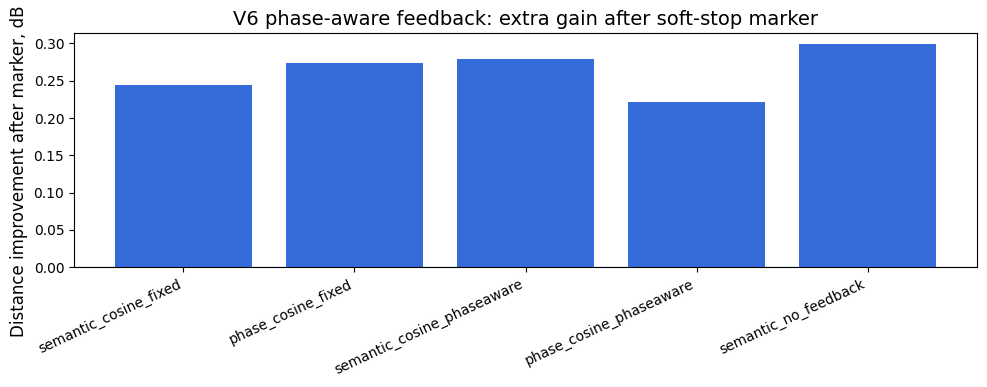

In [29]:

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = soft_stop.sort_values("mean_final_distance_db")
ax.bar(plot_df["strategy"], plot_df["mean_extra_gain_db_after_ready"])
ax.axhline(0, linewidth=1, alpha=0.4)
ax.set_title("V6 phase-aware feedback: extra gain after soft-stop marker")
ax.set_ylabel("Distance improvement after marker, dB RMS")
ax.set_xticklabels(plot_df["strategy"], rotation=25, ha="right")
plt.tight_layout()
savefig("v6_feedback_phaseaware_extra_gain_after_soft_stop.png")
plt.show()


## Inspect feedback events

Несколько строк, где виртуальный пользователь нажал feedback. Это полезно для проверки, что feedback не выбирается на каждом шаге и создаёт `feedback_recovery_contract` после себя.

In [30]:

feedback_events = records[records["feedback_used"] == True].copy()
cols = [
    "strategy", "target_mode", "step", "feedback_label", "feedback_probability",
    "feedback_best_label_cosine", "feedback_badness_score", "feedback_ambiguity_score",
    "feedback_misalignment_score", "distance_to_target_z", "distance_to_target_db_rms",
]
feedback_events[cols].head(30)


,strategy,target_mode,step,feedback_label,feedback_probability,feedback_best_label_cosine,feedback_badness_score,feedback_ambiguity_score,feedback_misalignment_score,distance_to_target_z,distance_to_target_db_rms
2005,semantic_cosine_fixed,semantic6d,6,more_air,0.066751,0.840137,0.194068,0.673689,0.756671,0.433636,0.918395
2021,semantic_cosine_fixed,semantic6d,22,too_thin,0.047342,0.719055,0.105952,0.834441,0.897172,0.194045,0.278739
2030,semantic_cosine_fixed,semantic6d,6,too_boomy,0.047853,0.590471,0.980135,0.049692,0.224882,1.941460,4.113953
2044,semantic_cosine_fixed,semantic6d,20,too_boomy,0.056197,0.553232,0.440297,0.174513,0.586830,0.881930,1.811598
2087,semantic_cosine_fixed,semantic4d,13,too_dark,0.022528,0.582637,0.095146,0.178090,0.461360,0.392468,0.462830
2111,semantic_cosine_fixed,semantic6d,12,too_harsh,0.027027,0.543700,0.189472,0.083097,0.438432,0.750396,1.539127
2130,semantic_cosine_fixed,random8d,6,too_much_bass,0.014491,0.219957,0.966086,0.291673,0.590083,1.868199,2.081264
2158,semantic_cosine_fixed,semantic6d,9,too_bright,0.022396,0.773509,0.324712,0.023809,0.164190,0.835581,2.225307
2163,semantic_cosine_fixed,semantic6d,14,less_air,0.097032,0.691302,0.284003,0.738970,0.868424,0.479862,0.822806
2199,semantic_cosine_fixed,semantic4d,25,too_harsh,0.031563,0.420703,0.081545,0.292956,0.657757,0.312905,0.492072


## Quick conclusion helper

In [31]:

# Lower final_distance_db_rms is better; lower feedback_count means less interruption.
# Compare against semantic_no_feedback to see whether in-session feedback helped.
base = verdict[verdict["strategy"] == "semantic_no_feedback"].iloc[0]
rows = []
for _, row in verdict.iterrows():
    rows.append({
        "strategy": row["strategy"],
        "delta_final_db_vs_no_feedback": float(row["mean_final_distance_db_rms"] - base["mean_final_distance_db_rms"]),
        "delta_final_z_vs_no_feedback": float(row["mean_final_distance_z"] - base["mean_final_distance_z"]),
        "mean_feedback_count": float(row["mean_feedback_count"]),
        "mean_feedback_rate": float(row["mean_feedback_rate"]),
        "mean_final_max_abs_db": float(row["mean_final_max_abs_db"]),
    })
conclusion_table = pd.DataFrame(rows).sort_values("delta_final_db_vs_no_feedback")
conclusion_table.to_csv(TABLES_DIR / "v6_feedback_phaseaware_delta_vs_baseline.csv", index=False)
conclusion_table


,strategy,delta_final_db_vs_no_feedback,delta_final_z_vs_no_feedback,mean_feedback_count,mean_feedback_rate,mean_final_max_abs_db
0,semantic_cosine_fixed,-0.127585,-0.058661,1.2250,0.0490,7.852772
1,phase_cosine_fixed,-0.068174,-0.029756,1.2875,0.0515,7.494475
2,semantic_cosine_phaseaware,-0.061689,-0.039861,1.1250,0.0450,7.659480
3,phase_cosine_phaseaware,-0.048987,-0.022971,1.2500,0.0500,7.270327
4,semantic_no_feedback,0.000000,0.000000,0.0000,0.0000,7.436496
